In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

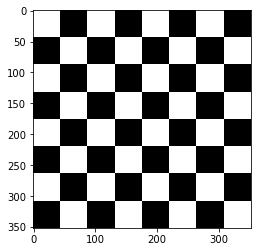

In [3]:
flat_chess = cv2.imread(r"C:\Users\monukoru\Downloads\image processing python\DATA\flat_chessboard.png",0).astype(np.float32)
real_chess = cv2.imread(r"C:\Users\monukoru\Downloads\image processing python\DATA\real_chessboard.jpg",0).astype(np.float32)
plt.imshow(flat_chess, cmap='gray')   #always convert to grayscale and float32 

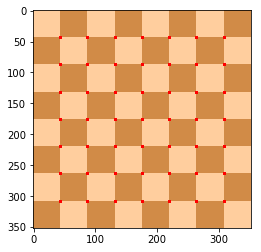

In [4]:
flat_chess_c = cv2.imread(r"C:\Users\monukoru\Downloads\image processing python\DATA\flat_chessboard.png")
flat_chess_c = cv2.cvtColor(flat_chess_c, cv2.COLOR_BGR2RGB)
                                                                #here we have used a special mask called as the boolean mask. when you put that directly into an image
                                                                # it manipulates the color the way you want them here we are doing using np.where() function 
                                                                # check it's syntax when needed. Its alternative is:- flat_chess_c[dst>0.1*dst.max()] = [255,0,0]
                                                                # always convert the image to graysacle and 32bit float in one line for (corner dectection) better optimization
                                                                # and then display it on a fresh copy of the image 
dst = cv2.cornerHarris(flat_chess,blockSize=2,ksize=3,k=0.04)
dst = cv2.dilate(dst, None)                         
mask = np.where(dst>0.1*dst.max(), True, False)
flat_chess_c[mask] =[255,0,0] 
plt.imshow(flat_chess_c)

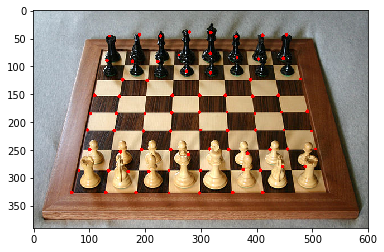

In [5]:
# This method is shi-tomasi corner detection 
real_chess_c = cv2.imread(r"C:\Users\monukoru\Downloads\image processing python\DATA\real_chessboard.jpg")
real_chess_c = cv2.cvtColor(real_chess_c, cv2.COLOR_BGR2RGB)

corners = cv2.goodFeaturesToTrack(real_chess, 0, 0.1,30)
corners = corners.astype(np.int64)

                                                   # shi-tomasi method directly gives the x and y co-ordinates as an array without any color channel so you have to loop it 
                                                   # manually and use cv2.circle() to highlight corners. This method will give you float array which you have to convert back to int
                                                   # check out the parameters of this cv2.goodFeaturesToTrack()  
for i in corners:
    x,y=i.ravel()
    cv2.circle(real_chess_c, (x,y), 3, (255,0,0),-1)
                   
plt.imshow(real_chess_c)